# 01 - Quick EDA: Mango ripeness (VIS camera)
Hard timebox. Aggregate plots only (counts, mean spectra, PCA): no dataset images in this notebook.
Input: `data/processed/spectra.parquet` from `make features`. Label = ripeness class of the physical fruit
(unripe / perfect / overripe), measured on the fruit's last imaging day.

In [1]:
import os, pathlib
here = pathlib.Path.cwd()
os.chdir(next(p for p in [here, *here.parents] if (p / "pyproject.toml").exists()))  # repo root

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fruithsi.preprocess import transform

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CLASSES = ["unripe", "perfect", "overripe"]
COLORS = {"unripe": "#3d9970", "perfect": "#e8a33d", "overripe": "#8c4a2f"}

df = pd.read_parquet("data/processed/spectra.parquet")
bands = [c for c in df if c.startswith("nm_")]
wl = np.array([float(c[3:]) for c in bands])
lab = df[df.labelled].reset_index(drop=True)
fruit = lab.drop_duplicates("fruit_id").set_index("fruit_id")
X = lab[bands].to_numpy()
print(f"{len(df)} images, {df.fruit_id.nunique()} physical fruits, {len(bands)} bands; "
      f"{len(lab)} labelled images from {lab.fruit_id.nunique()} fruits")

562 images, 40 physical fruits, 192 bands; 80 labelled images from 40 fruits


## 1. Label distribution and images per physical fruit

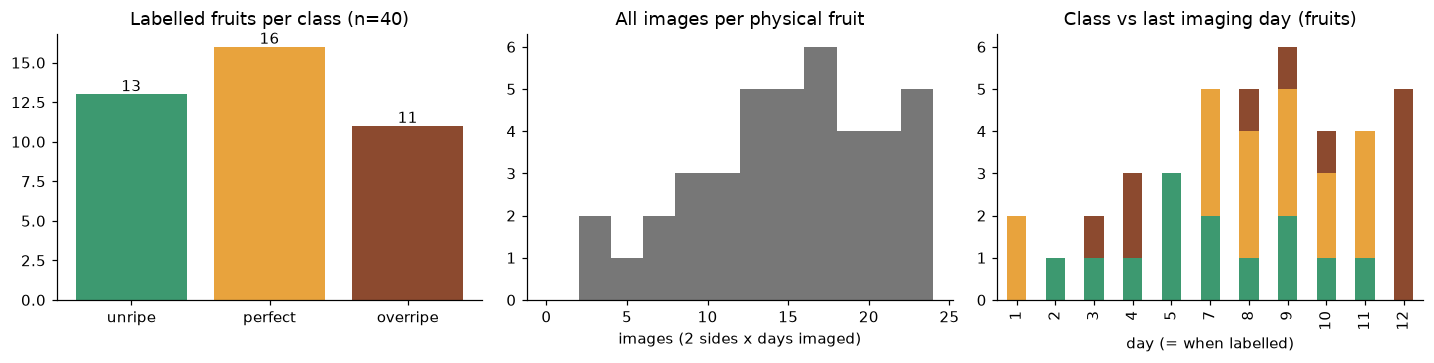

labelled images per fruit: [2] | unlabelled images: 482


In [2]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
n_fruit = fruit.ripeness.value_counts().reindex(CLASSES)
ax[0].bar(CLASSES, n_fruit, color=[COLORS[c] for c in CLASSES])
for i, v in enumerate(n_fruit): ax[0].text(i, v + 0.2, str(v), ha="center")
ax[0].set_title("Labelled fruits per class (n=40)")

per_fruit_all = df.groupby("fruit_id").size()
ax[1].hist(per_fruit_all, bins=range(0, 25, 2), color="#777")
ax[1].set_title("All images per physical fruit"); ax[1].set_xlabel("images (2 sides x days imaged)")

ct = pd.crosstab(fruit.day, fruit.ripeness).reindex(columns=CLASSES, fill_value=0)
ct.plot.bar(stacked=True, ax=ax[2], color=[COLORS[c] for c in CLASSES], legend=False)
ax[2].set_title("Class vs last imaging day (fruits)"); ax[2].set_xlabel("day (= when labelled)")
plt.tight_layout(); plt.show()
print("labelled images per fruit:", lab.groupby("fruit_id").size().unique(), "| unlabelled images:", (~df.labelled).sum())

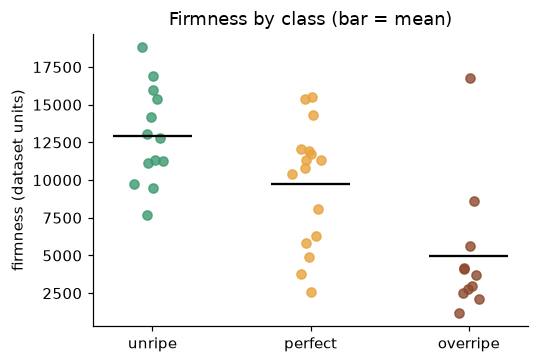

          count     mean     std     min      max
ripeness                                         
unripe       13  12904.0  3230.0  7699.0  18800.0
perfect      16   9766.0  4055.0  2600.0  15500.0
overripe     11   4955.0  4389.0  1200.0  16750.0


In [3]:
fig, ax = plt.subplots(figsize=(5, 3.4))
for i, c in enumerate(CLASSES):
    v = fruit[fruit.ripeness == c].firmness
    ax.scatter(np.random.default_rng(0).normal(i, 0.05, len(v)), v, color=COLORS[c], alpha=0.8)
    ax.hlines(v.mean(), i - 0.25, i + 0.25, color="k")
ax.set_xticks(range(3), CLASSES); ax.set_ylabel("firmness (dataset units)")
ax.set_title("Firmness by class (bar = mean)"); plt.tight_layout(); plt.show()
print(fruit.groupby("ripeness").firmness.agg(["count", "mean", "std", "min", "max"]).round(0).loc[CLASSES])

## 2. Mean spectra by class: raw vs SNV vs Savitzky-Golay derivative (mean ± 1 sd over labelled images)

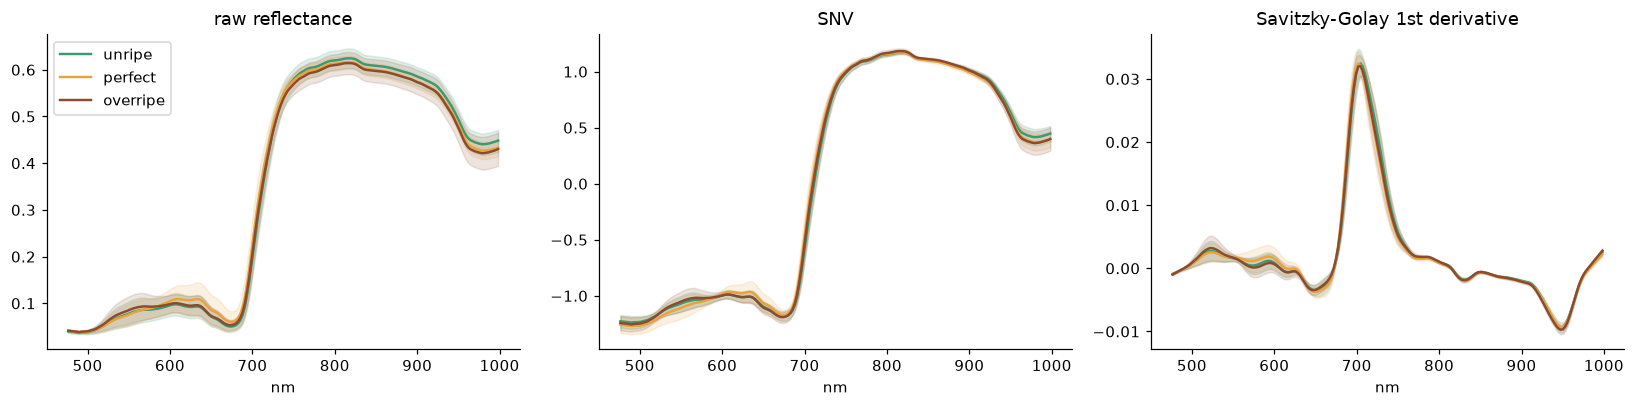

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
for a, (m, title) in zip(ax, [("raw", "raw reflectance"), ("snv", "SNV"), ("sg1", "Savitzky-Golay 1st derivative")]):
    Z = transform(X, m)
    for c in CLASSES:
        z = Z[(lab.ripeness == c).to_numpy()]
        a.plot(wl, z.mean(0), color=COLORS[c], label=c, lw=1.6)
        a.fill_between(wl, z.mean(0) - z.std(0), z.mean(0) + z.std(0), color=COLORS[c], alpha=0.15)
    a.set_title(title); a.set_xlabel("nm")
ax[0].legend(); plt.tight_layout(); plt.show()

## 3. Where do the classes differ? Per-band Fisher ratio (between-class / within-class variance)

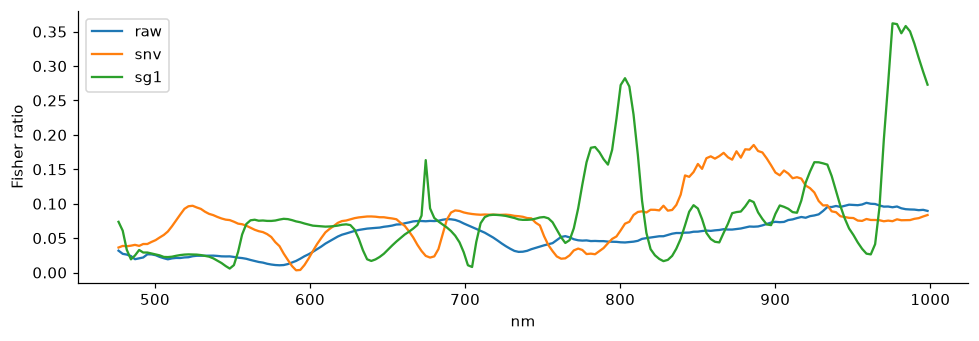

raw  top bands (nm): [948.0, 956.0, 959.0, 962.0, 964.0]  max ratio 0.10
snv  top bands (nm): [875.0, 881.0, 883.0, 886.0, 889.0]  max ratio 0.19
sg1  top bands (nm): [976.0, 978.0, 981.0, 984.0, 987.0]  max ratio 0.36


In [5]:
def fisher_per_band(Z, y):
    mu = Z.mean(0); num = 0; den = 0
    for c in CLASSES:
        z = Z[y == c]; num = num + len(z) * (z.mean(0) - mu) ** 2; den = den + ((z - z.mean(0)) ** 2).sum(0)
    return num / den

y = lab.ripeness.to_numpy()
fig, ax = plt.subplots(figsize=(9, 3.2))
for m in ["raw", "snv", "sg1"]:
    ax.plot(wl, fisher_per_band(transform(X, m), y), label=m)
ax.set_xlabel("nm"); ax.set_ylabel("Fisher ratio"); ax.legend(); plt.tight_layout(); plt.show()
for m in ["raw", "snv", "sg1"]:
    f = fisher_per_band(transform(X, m), y); top = np.argsort(f)[::-1][:5]
    print(f"{m:4s} top bands (nm): {np.sort(wl[top]).round(0).tolist()}  max ratio {f.max():.2f}")

## 4. PCA and a simple class-separability score per transform (descriptive, not a model metric)

transform  PC1 var  PC1+2 var  separability (5 PCs)
      raw    0.469      0.846                 0.057
      snv    0.712      0.928                 0.076
      sg1    0.710      0.879                 0.065
  snv_sg1    0.731      0.936                 0.063


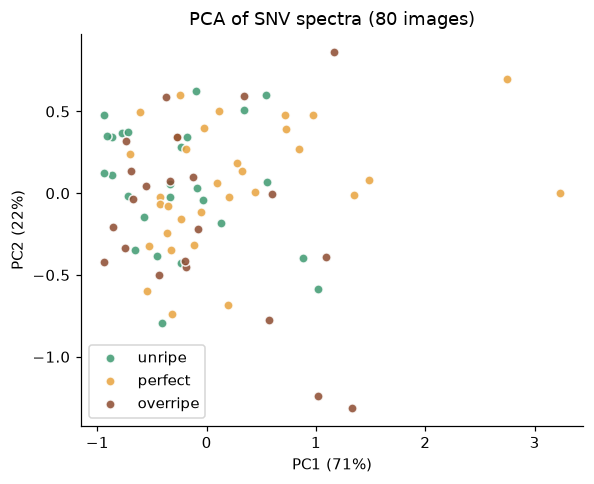

In [6]:
def pca(Z, k=5):
    Zc = Z - Z.mean(0); u, s, vt = np.linalg.svd(Zc, full_matrices=False)
    return u[:, :k] * s[:k], s[:k] ** 2 / (s ** 2).sum()

def separability(S, y):
    # trace(between-class scatter) / trace(within-class scatter) in PC space; >1 = classes apart
    mu = S.mean(0); sb = sum(len(S[y == c]) * ((S[y == c].mean(0) - mu) ** 2).sum() for c in CLASSES)
    sw = sum(((S[y == c] - S[y == c].mean(0)) ** 2).sum() for c in CLASSES)
    return sb / sw

rows = []
for m in ["raw", "snv", "sg1", "snv_sg1"]:
    S, ev = pca(transform(X, m)); rows.append({"transform": m, "PC1 var": ev[0], "PC1+2 var": ev[:2].sum(),
                                              "separability (5 PCs)": separability(S, y)})
print(pd.DataFrame(rows).round(3).to_string(index=False))

S, ev = pca(transform(X, "snv"), 2)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for c in CLASSES:
    k = (y == c)
    ax.scatter(S[k, 0], S[k, 1], color=COLORS[c], label=c, alpha=0.85, edgecolor="w")
ax.set_xlabel(f"PC1 ({ev[0]:.0%})"); ax.set_ylabel(f"PC2 ({ev[1]:.0%})"); ax.set_title("PCA of SNV spectra (80 images)")
ax.legend(); plt.tight_layout(); plt.show()

## 5. Two sides of one fruit vs different fruits (why the split must be grouped)

In [7]:
Z = transform(X, "snv")
fb = [np.linalg.norm(Z[g.index[0]] - Z[g.index[1]]) for _, g in lab.groupby("fruit_id")]
fr_idx = lab.drop_duplicates("fruit_id").index.to_numpy()
other = [np.linalg.norm(Z[a] - Z[b]) for i, a in enumerate(fr_idx) for b in fr_idx[i + 1:]]
same = [np.linalg.norm(Z[a] - Z[b]) for i, a in enumerate(fr_idx) for b in fr_idx[i + 1:] if y[a] == y[b]]
print(f"SNV distance, front vs back of the SAME fruit : median {np.median(fb):.2f}")
print(f"SNV distance, different fruits, SAME class     : median {np.median(same):.2f}")
print(f"SNV distance, different fruits (any class)     : median {np.median(other):.2f}")

SNV distance, front vs back of the SAME fruit : median 0.62
SNV distance, different fruits, SAME class     : median 0.92
SNV distance, different fruits (any class)     : median 0.92


## 6. A textbook chlorophyll index per class, and within- vs between-fruit variation

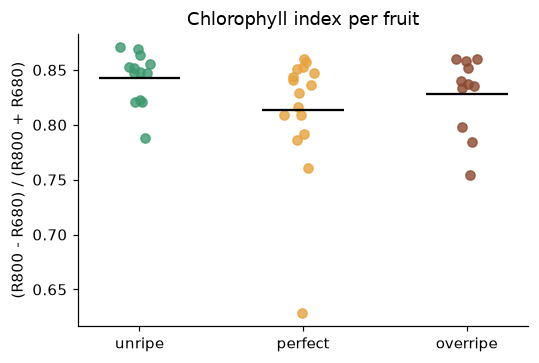

           mean    std
ripeness              
unripe    0.843  0.024
perfect   0.814  0.057
overripe  0.828  0.035
Kruskal-Wallis p = 0.188
Spearman(firmness, index) = 0.21


In [8]:
from scipy import stats
def band_at(nm): return lab[bands[np.abs(wl - nm).argmin()]].to_numpy()
lab["ndvi"] = (band_at(800) - band_at(680)) / (band_at(800) + band_at(680))   # chlorophyll proxy
per_fruit = lab.groupby("fruit_id").agg(ripeness=("ripeness", "first"), ndvi=("ndvi", "mean"), firmness=("firmness", "first"))

fig, ax = plt.subplots(figsize=(5, 3.4))
for i, c in enumerate(CLASSES):
    v = per_fruit[per_fruit.ripeness == c].ndvi
    ax.scatter(np.random.default_rng(0).normal(i, 0.05, len(v)), v, color=COLORS[c], alpha=0.8)
    ax.hlines(v.mean(), i - 0.25, i + 0.25, color="k")
ax.set_xticks(range(3), CLASSES); ax.set_ylabel("(R800 - R680) / (R800 + R680)"); ax.set_title("Chlorophyll index per fruit")
plt.tight_layout(); plt.show()
print(per_fruit.groupby("ripeness").ndvi.agg(["mean", "std"]).round(3).loc[CLASSES])
print("Kruskal-Wallis p =", round(stats.kruskal(*[per_fruit[per_fruit.ripeness == c].ndvi for c in CLASSES]).pvalue, 3))
print("Spearman(firmness, index) =", np.round(stats.spearmanr(per_fruit.firmness, per_fruit.ndvi)[0], 2))

## Findings (for the README)
1. **Small, noisy label set.** 40 labelled fruits (13 unripe / 16 perfect / 11 overripe), 2 images each (front and back); the other 482 VIS images are earlier days of the same fruits and have no label. The majority-class baseline is 40% of fruits (perfect).
2. **Classes look almost the same spectrally.** All class means share the usual vegetation profile (chlorophyll dip near 680 nm, red edge 700-750 nm, NIR plateau, water dip near 970 nm). Differences between class means are small next to the ±1 sd bands, PCA of SNV spectra overlaps heavily, and the between/within scatter ratio is only 0.06-0.08 for every transform.
3. **Where the classes do differ most** (per-band Fisher ratio): the first derivative near 800 nm and 975-990 nm (water absorption region), and SNV in 830-900 nm. A chlorophyll index (R800-R680)/(R800+R680) is highest for unripe fruit as expected, but perfect vs overripe are not ordered and no difference is significant with n=40 (Kruskal-Wallis p~0.19).
4. **Fruit identity beats class.** Front vs back of the same fruit are closer (median SNV distance 0.62) than two different fruits of the same class (0.92), so images of one fruit are not independent: the split must be grouped by fruit, and a random split will look better than reality.
5. **Labels are only loosely tied to firmness** (mean 12.9k / 9.8k / 5.0k for unripe / perfect / overripe, but sd 3-4k and one 'overripe' fruit at 16.7k), so expect a ceiling on accuracy. Inside one fruit the pixel sd of the chlorophyll index equals the spread of whole-fruit means between fruits, so the fruit mean blurs a lot. Index maps (local notebook) show this is mostly a centre-to-rim illumination/geometry gradient seen in every class, plus some real skin-colour patches in a few fruits; the mean spectrum mixes both.

## Decisions for M5
- **Evaluation:** with 40 fruits one hold-out has ~8 test fruits, so the headline number is repeated stratified `GroupKFold` by `fruit_id` (mean ± sd over folds); the single grouped hold-out is shown next to it. Report image-level and fruit-level (average the 2 sides) accuracy and macro-F1, plus the confusion matrix. Baseline to beat: majority class (40% of fruits).
- **PLS-DA preprocessing:** SNV as the default (best separability), Savitzky-Golay 1st derivative as the one alternative; number of components chosen by an inner grouped CV on training folds only. No other tuning.
- **Leakage demo:** random split by image (front in train, back in test) should look better than the grouped split; expected from finding 4.
- **Do not** give earlier-day images of a fruit its final label (ripeness changes over time). The 482 unlabelled images stay unused.
- **For M6 (needs my OK before doing it):** with ~64 training images the 1D-CNN will overfit. Augmentation idea: mean of random subsets of mask pixels as extra training spectra (also exposes the model to the within-fruit geometry variation) (needs pixel spectra of the 80 labelled images, ~150 MB, not stored yet). Within the 3-configuration limit; expect PLS-DA to be competitive or better.